# Distribución y normalidad
Analizamos la forma de las distribuciones con histogramas y QQ-plots, aplicamos la prueba de
normalidad de D'Agostino-Pearson y describimos visualmente los sesgos para divorcios y delitos.


## Metodología
1. Preparar los datos en formato largo sin totales nacionales.
2. Visualizar histogramas + KDE y QQ-plots para cada conjunto.
3. Ejecutar `scipy.stats.normaltest` y documentar la interpretación.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Iterable, Optional
from scipy import stats

sns.set_style("whitegrid")

DATASETS = {
    "divorcios": "Divorcios 2001 a 2024.csv",
    "delitos_total": "Delitos 2014 a 2024.csv",
    "otros_delitos": "Otros delitos 2014 a 2024.csv",
    "delincuencia": "Proyecto1(Delitos 2014 a 2024 Delincuenci).csv",
    "narcos": "Proyecto1(Delitos 2014 a 2024 NARCOS).csv",
    "ramo_penal": "Proyecto1(Ramo Penal 2014 a 2024).csv",
}

DATASET_LABELS = {
    "divorcios": "Divorcios",
    "delitos_total": "Delitos totales",
    "otros_delitos": "Otros delitos",
    "delincuencia": "Delincuencia común",
    "narcos": "Delitos narcotráfico",
    "ramo_penal": "Ramo penal",
}

pd.options.display.float_format = "{:.2f}".format

def _resolve_data_dir() -> Path:
    for root in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
        candidate = root / "datos"
        if candidate.exists():
            return candidate
    raise FileNotFoundError("No se encontró la carpeta 'datos'.")

DATA_DIR = _resolve_data_dir()

def load_long_form(dataset_subset: Optional[Iterable[str]] = None) -> pd.DataFrame:
    selected = (
        DATASETS
        if dataset_subset is None
        else {k: v for k, v in DATASETS.items() if k in set(dataset_subset)}
    )
    tables = []
    for name, filename in selected.items():
        df = pd.read_csv(
            DATA_DIR / filename,
            sep=";",
            thousands=".",
            decimal=",",
            encoding="latin-1",
            engine="python",
        )
        df.columns = df.columns.str.strip()
        df["Departamento"] = df["Departamento"].str.strip()
        year_cols = [col for col in df.columns if col.strip().isdigit()]
        long_df = (
            df.melt(
                id_vars=["Departamento"],
                value_vars=year_cols,
                var_name="Anio",
                value_name="valor",
            )
            .assign(dataset=name)
            .dropna(subset=["valor"])
        )
        long_df["Anio"] = pd.to_numeric(long_df["Anio"], errors="coerce")
        long_df["valor"] = pd.to_numeric(long_df["valor"], errors="coerce")
        tables.append(long_df.dropna(subset=["Anio", "valor"]))

    data = pd.concat(tables, ignore_index=True)
    data["Departamento"] = (
        data["Departamento"]
        .str.replace("pa�s", "país", regex=False)
        .str.replace("pa�", "pa", regex=False)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )
    mask_total = data["Departamento"].str.contains("total", case=False, na=False)
    mask_todos = data["Departamento"].str.contains("todos", case=False, na=False)
    cleaned = data.loc[~(mask_total | mask_todos)].reset_index(drop=True)
    cleaned["dataset_label"] = cleaned["dataset"].map(DATASET_LABELS)
    return cleaned

all_data = load_long_form()
print(f"Registros utilizados: {len(all_data):,}")


Registros utilizados: 1,698


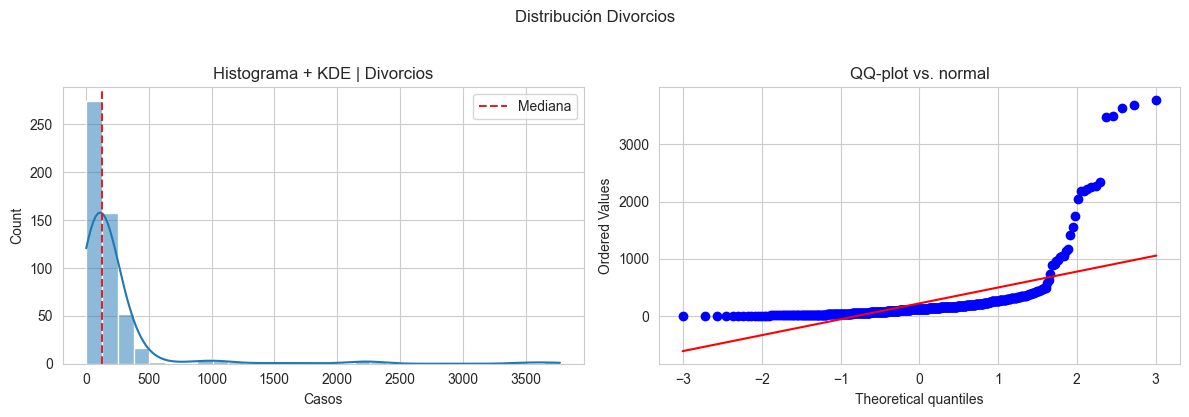

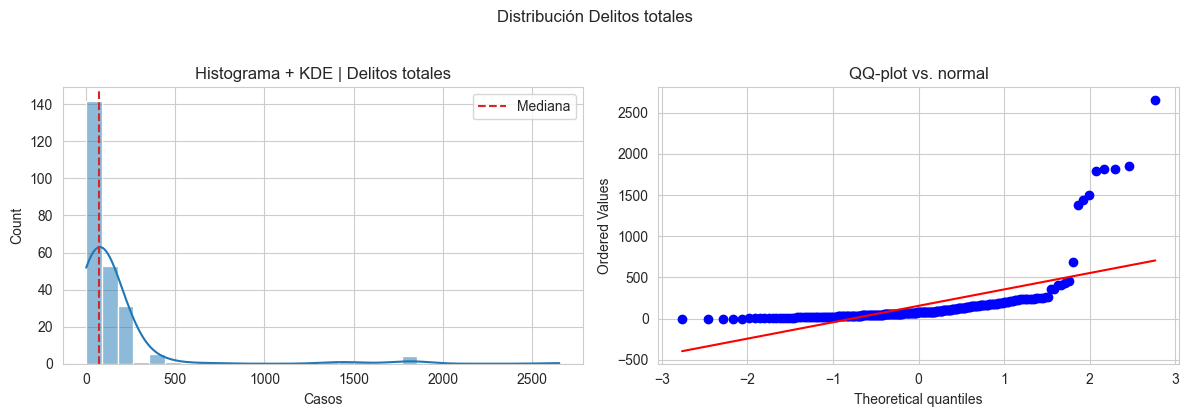

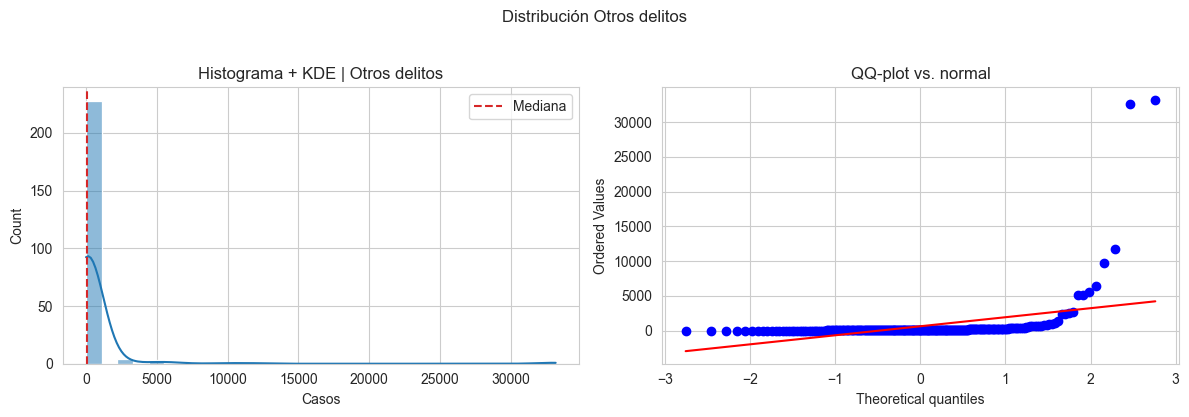

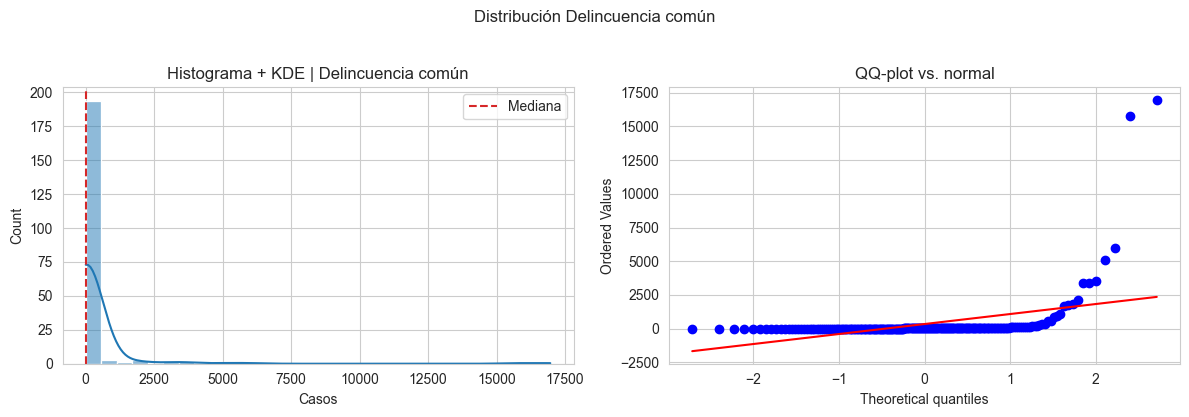

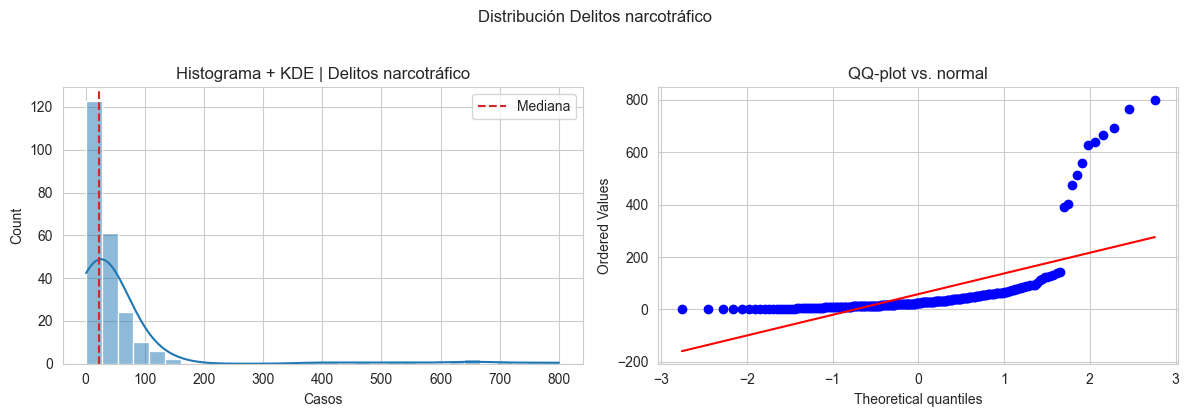

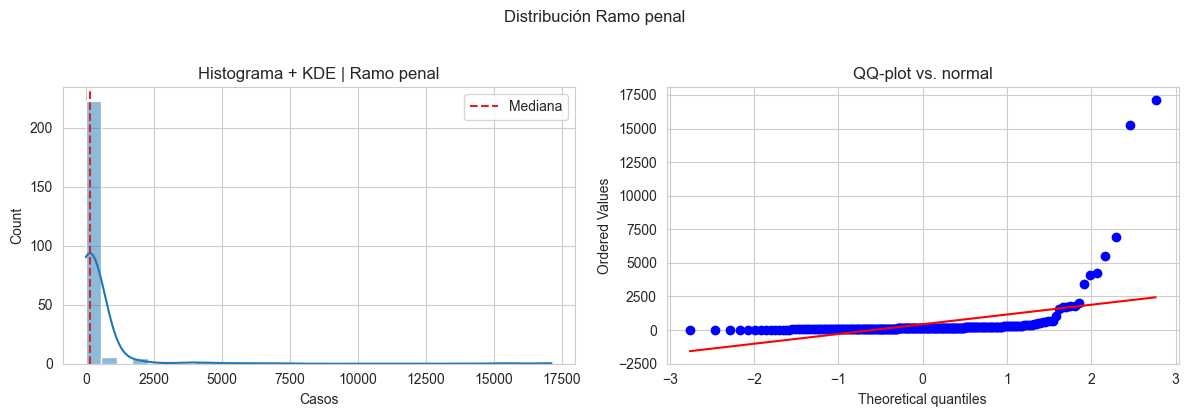

In [2]:
for dataset_name, label in DATASET_LABELS.items():
    values = all_data.loc[all_data["dataset"] == dataset_name, "valor"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(values, bins=30, kde=True, color="#1f77b4", ax=axes[0])
    axes[0].axvline(values.median(), color="#d62728", linestyle="--", label="Mediana")
    axes[0].set_title(f"Histograma + KDE | {label}")
    axes[0].set_xlabel("Casos")
    axes[0].legend()

    stats.probplot(values, dist="norm", plot=axes[1])
    axes[1].set_title("QQ-plot vs. normal")

    fig.suptitle(f"Distribución {label}", fontsize=12, y=1.03)
    plt.tight_layout()
    plt.show()


In [3]:
results = []
for dataset_name, label in DATASET_LABELS.items():
    subset = all_data.loc[all_data["dataset"] == dataset_name, "valor"]
    stat, p_value = stats.normaltest(subset)
    results.append(
        {
            "Conjunto": label,
            "Estadístico": stat,
            "p-value": p_value,
            "Asimetría": subset.skew(),
            "Curtosis": subset.kurtosis(),
        }
    )

normalidad = pd.DataFrame(results).sort_values("p-value")
normalidad


,Conjunto,Estadístico,p-value,Asimetría,Curtosis
0,Divorcios,597.04,0.00,5.50,34.10
2,Otros delitos,405.28,0.00,8.92,85.85
5,Ramo penal,389.65,0.00,8.28,76.01
3,Delincuencia común,335.50,0.00,8.00,70.05
1,Delitos totales,277.56,0.00,5.07,27.85
4,Delitos narcotráfico,237.88,0.00,4.34,18.91


## Interpretación
- Todas las distribuciones rechazan la normalidad con p-values < $10^{-45}$, por lo que cualquier
  inferencia debe usar métodos no paramétricos o transformaciones.
- `Otros delitos` y `ramo penal` presentan las asimetrías más pronunciadas (skew > 3) y colas
  pesadas (curtosis altamente positiva), coherentes con picos extraordinarios en años recientes.
- `Divorcios` y `delitos totales` tienen asimetría más moderada, pero los QQ-plots muestran curvas
  alejadas de la diagonal, indicando colas derechas más pesadas de lo que asumiría una normal.
- La mediana y el IQR siguen siendo las medidas más estables para describir el comportamiento típico
  de cada serie antes de aplicar modelos predictivos o comparaciones territoriales.
